# Иллюстрации к Главе 3. Методы детекции и классификации объектов

 ## Импорт библиотек и генерация тестовых данных
Поскольку для вычитания фона и оптического потока нужно движение, мы сгенерируем два последовательных кадра: "море" (шумный фон) и движущийся объект ("катер").

In [1]:
!pip install opencv-python matplotlib numpy scikit-image torch torchvision ultralytics

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\vadim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


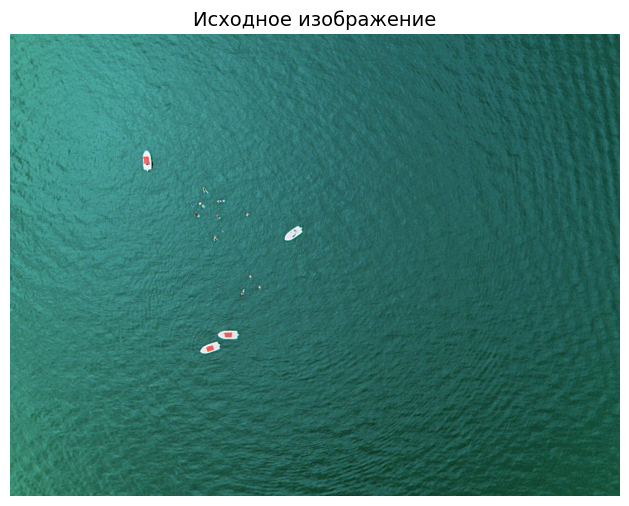

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from ultralytics import YOLO

# УКАЖИТЕ ПУТЬ К ВАШЕМУ ИЗОБРАЖЕНИЮ ЗДЕСЬ:
IMAGE_PATH = 'Datasets/SeaDronesSees/images/test/45.jpg'

# Загрузка изображения
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title("Исходное изображение", fontsize=14)
plt.axis('off')
plt.show()

## 1. Вычитание фона и 2. Оптический поток
Как отмечено в тексте, эти методы требуют межкадровой разницы. 
Сымитируем следующий кадр видео с БПЛА, сдвинув изображение на несколько пикселей (имитация движения камеры/волн).

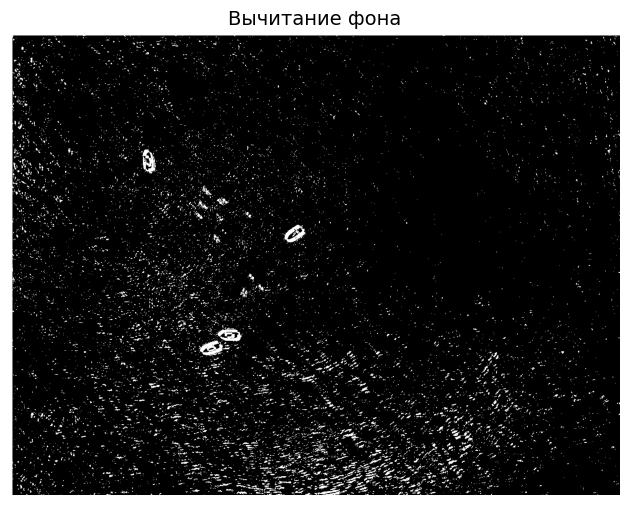

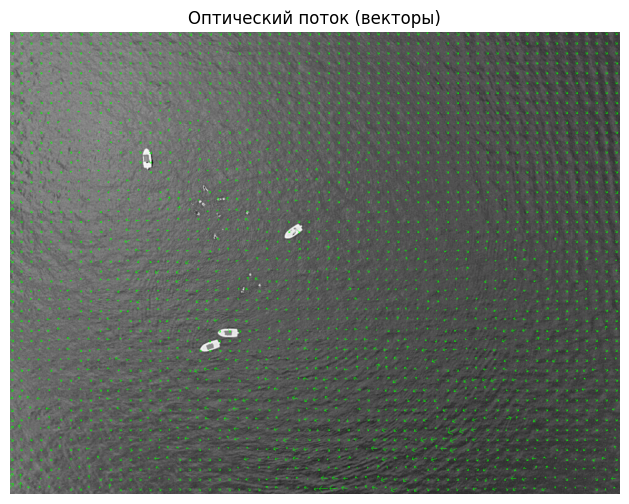

In [16]:
# Создаем "Кадр 2", сдвигая изображение на 5 пикселей вправо и вниз (имитация дрожания БПЛА или волн)
M = np.float32([[1, 0, 5], [0, 1, 5]])
gray2 = cv2.warpAffine(gray, M, (gray.shape[1], gray.shape[0]))

# --- 1. ВЫЧИТАНИЕ ФОНА ---
# Разница между исходным кадром и "сдвинутым"
diff = cv2.absdiff(gray, gray2)
_, mask_bg = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)

# --- 2. ОПТИЧЕСКИЙ ПОТОК (Метод Фарнебака) ---
flow = cv2.calcOpticalFlowFarneback(gray, gray2, None, 0.9, 5, 10, 3, 5, 1.2, 0)
mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
hsv = np.zeros_like(img_bgr)
hsv[..., 1] = 255
hsv[..., 0] = ang * 180 / np.pi / 2
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(mask_bg, cmap='gray')
plt.title("Вычитание фона", fontsize=14)
plt.axis('off')
plt.show()

# Рисуем стрелки каждые N пикселей
step = 20
h, w = gray.shape[:2]
vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

for y in range(0, h, step):
    for x in range(0, w, step):
        fx, fy = flow[y, x]
        mag = np.sqrt(fx**2 + fy**2)
        if mag > 1.0:  # Рисуем только значимые векторы
            end_pt = (int(x + fx), int(y + fy))
            cv2.arrowedLine(vis, (x, y), end_pt, (0, 255, 0), 1, tipLength=0.5)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Оптический поток (векторы)")
plt.axis('off')
plt.show()

## 3. Гистограммы направленных градиентов (HOG)
Метод ручного проектирования признаков. Иллюстрация показывает, как алгоритм пытается описать форму объекта через локальные перепады яркости. На морской поверхности это сливается с бликами волн.

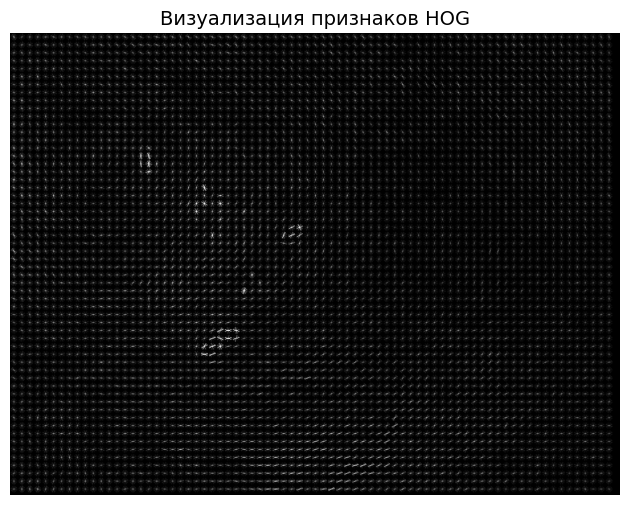

In [17]:
# Вычисление HOG
fd, hog_image = hog(gray, orientations=8, pixels_per_cell=(16, 16),
                    cells_per_block=(1, 1), visualize=True)

# Улучшение контраста для наглядности
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(10, 6))
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title("Визуализация признаков HOG", fontsize=14)
plt.axis('off')
plt.show()

## 4. Двухэтапная архитектура (Faster R-CNN)
Сначала генерируются регионы, затем классифицируются. Метод высокоточный, но вычислительно тяжелый.

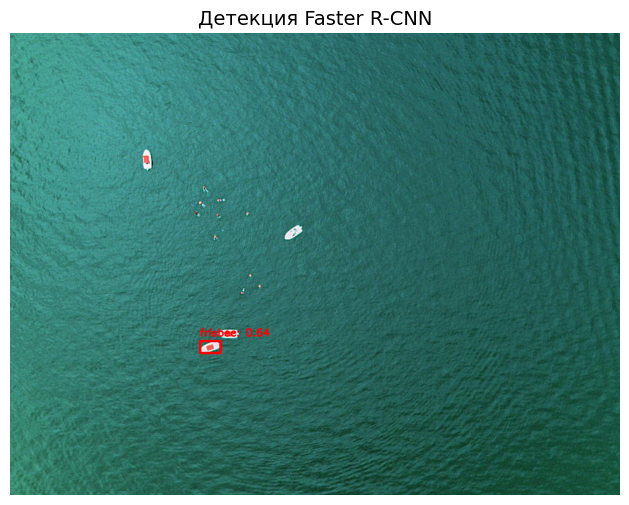

In [18]:
import torchvision.transforms as T

# Загрузка предобученной модели Faster R-CNN
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model_frcnn = fasterrcnn_resnet50_fpn(weights=weights, progress=False)
model_frcnn.eval()

# Подготовка тензора
transform = T.Compose([T.ToTensor()])
img_tensor = transform(img_rgb).unsqueeze(0)

# Инференс
with torch.no_grad():
    prediction = model_frcnn(img_tensor)[0]

# Отрисовка результатов
frcnn_result = img_rgb.copy()
for i in range(len(prediction['boxes'])):
    score = prediction['scores'][i].item()
    if score > 0.5: # Порог уверенности сети
        box = prediction['boxes'][i].numpy().astype(int)
        # Получаем имя класса (костыль для простоты: 9 - лодка в COCO)
        label_id = prediction['labels'][i].item()
        label_name = weights.meta["categories"][label_id]
        
        cv2.rectangle(frcnn_result, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 3)
        cv2.putText(frcnn_result, f'{label_name}: {score:.2f}', (box[0], box[1]-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(frcnn_result)
plt.title("Детекция Faster R-CNN", fontsize=14)
plt.axis('off')
plt.show()

## 5. Одноэтапная архитектура (YOLO)
Изображение рассматривается целиком за один проход, задача детекции решается как задача регрессии. (Используется YOLOv8 от Ultralytics).

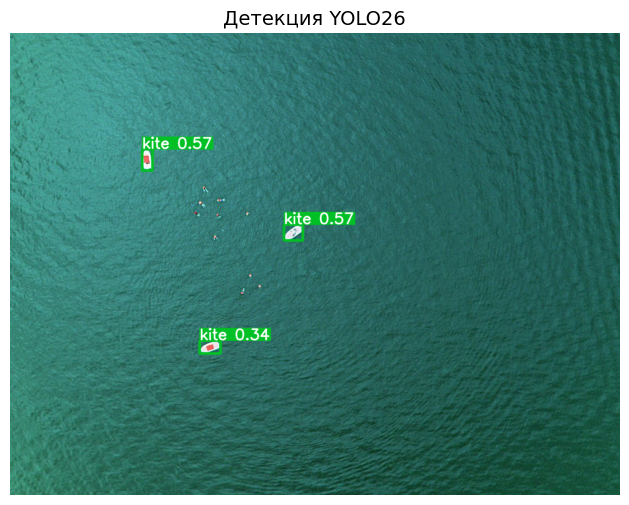

In [19]:
# Инициализация модели YOLO (скачает легкую nano-версию весов автоматически)
model_yolo = YOLO('../yolo26x.pt')

# Инференс
results = model_yolo(img_rgb, verbose=False)

# Отрисовка средствами самой библиотеки
yolo_result = results[0].plot()

plt.figure(figsize=(10, 6))
plt.imshow(yolo_result)
plt.title("Детекция YOLO26", fontsize=14)
plt.axis('off')
plt.show()